# Task 1 — Data Exploration
## Synthetic Purchase History Dataset

This notebook explores the generated purchase history dataset for the purchase prediction task.

We will:
- load the generated CSV files
- inspect dataset structure
- plot order count by product
- plot order count by customer type
- plot order count by season
- check for missing values
- assess imbalance in the `is_reorder` target
- document limitations that should be discussed in the technical report

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/raw")

orders_path = DATA_DIR / "orders.csv"
customers_path = DATA_DIR / "customers.csv"
producers_path = DATA_DIR / "producers.csv"
products_path = DATA_DIR / "products.csv"

print("Orders path   :", orders_path.resolve())
print("Customers path:", customers_path.resolve())
print("Producers path:", producers_path.resolve())
print("Products path :", products_path.resolve())

Orders path   : /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction/data/raw/orders.csv
Customers path: /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction/data/raw/customers.csv
Producers path: /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction/data/raw/producers.csv
Products path : /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction/data/raw/products.csv


## 1. Load the CSV Files

The dataset was generated synthetically and saved into the `data/raw/` directory.

In [2]:
orders_df = pd.read_csv(orders_path)
customers_df = pd.read_csv(customers_path)
producers_df = pd.read_csv(producers_path)
products_df = pd.read_csv(products_path)

print("orders_df shape   :", orders_df.shape)
print("customers_df shape:", customers_df.shape)
print("producers_df shape:", producers_df.shape)
print("products_df shape :", products_df.shape)

orders_df.head()

orders_df shape   : (2500, 11)
customers_df shape: (15, 2)
producers_df shape: (8, 3)
products_df shape : (12, 4)


,order_id,customer_id,customer_type,producer_id,product,quantity,unit_price,order_date,month,season,is_reorder
0,ORD001028,CUST006,restaurant,PROD004,Apples,16,2.06,2023-01-01,1,winter,1
1,ORD002254,CUST004,household,PROD006,Potatoes,6,1.32,2023-01-01,1,winter,1
2,ORD001712,CUST014,restaurant,PROD001,Potatoes,20,1.30,2023-01-02,1,winter,1
3,ORD001569,CUST001,household,PROD003,Croissant,3,1.08,2023-01-02,1,winter,1
4,ORD000542,CUST012,hotel,PROD008,Strawberries,6,3.38,2023-01-02,1,winter,1


## 2. Dataset Structure

This gives a quick overview of the columns, data types, and whether the values align with the intended schema.

In [3]:
orders_df.info()

orders_df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       2500 non-null   object 
 1   customer_id    2500 non-null   object 
 2   customer_type  2500 non-null   object 
 3   producer_id    2500 non-null   object 
 4   product        2500 non-null   object 
 5   quantity       2500 non-null   int64  
 6   unit_price     2500 non-null   float64
 7   order_date     2500 non-null   object 
 8   month          2500 non-null   int64  
 9   season         2500 non-null   object 
 10  is_reorder     2500 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 215.0+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,2500,2500,ORD001028,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,2500,15,CUST012,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_type,2500,5,household,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
producer_id,2500,8,PROD006,472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,2500,12,Milk,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,2500.0,NaN,NaN,NaN,10.8508,8.896212,1.0,4.0,8.0,15.0,56.0
unit_price,2500.0,NaN,NaN,NaN,1.904172,1.132712,0.9,1.23,1.51,2.03,7.4
order_date,2500,709,2024-07-28,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,2500.0,NaN,NaN,NaN,6.5736,3.436351,1.0,4.0,7.0,10.0,12.0
season,2500,4,spring,655,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Findings — Dataset Structure

- The dataset contains one row per order.
- The main predictive target is `is_reorder`, which indicates whether the customer has ordered that product before.
- The fields include customer context (`customer_id`, `customer_type`), producer context (`producer_id`), product information (`product`, `unit_price`, `quantity`), and time-based features (`order_date`, `month`, `season`).
- Because the dataset is synthetic, the schema is clean and strongly structured, which is useful for model development but less representative of messy real-world operational data.

## 3. Order Count by Product

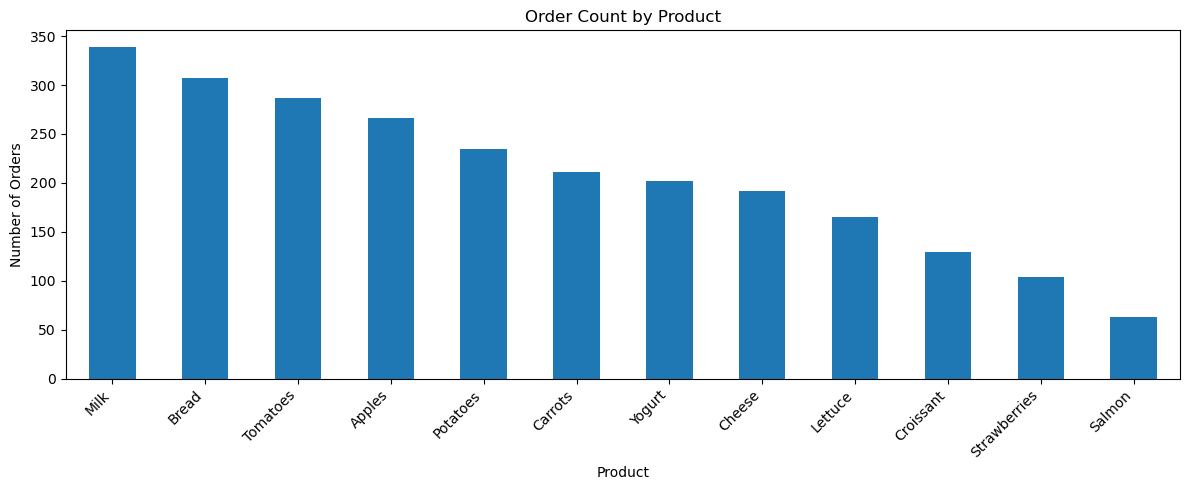

,order_count
product,
Milk,339
Bread,307
Tomatoes,287
Apples,266
Potatoes,235
Carrots,211
Yogurt,202
Cheese,192
Lettuce,165


In [4]:
product_counts = orders_df["product"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
product_counts.plot(kind="bar")
plt.title("Order Count by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

product_counts.to_frame("order_count")

### Findings — Product Distribution

- Order volume is not perfectly uniform across products.
- This is expected because the generator intentionally applies different customer preferences and seasonal demand multipliers.
- Products associated with everyday consumption are likely to appear more often, while others may have fewer orders.
- This introduces product-level bias into the dataset, which improves realism slightly, but it also means the model may learn product popularity patterns more strongly than deeper behavioural relationships.

## 4. Order Count by Customer Type

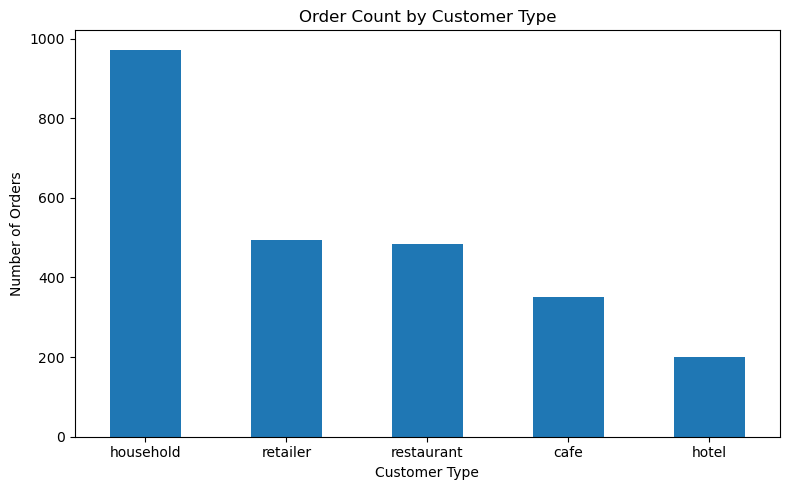

,order_count
customer_type,
household,972
retailer,494
restaurant,485
cafe,350
hotel,199


In [5]:
customer_type_counts = orders_df["customer_type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
customer_type_counts.plot(kind="bar")
plt.title("Order Count by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

customer_type_counts.to_frame("order_count")

### Findings — Customer Type Distribution

- The dataset contains multiple customer types, such as household, restaurant, retailer, cafe, and hotel.
- If one or two customer groups dominate the order volume, the model may become more tuned to those groups than to the smaller ones.
- This matters because reorder behaviour can differ substantially across customer segments.
- For example, restaurants and retailers may show more consistent repeat purchasing than households, so an uneven distribution may influence the target patterns.

## 5. Order Count by Season

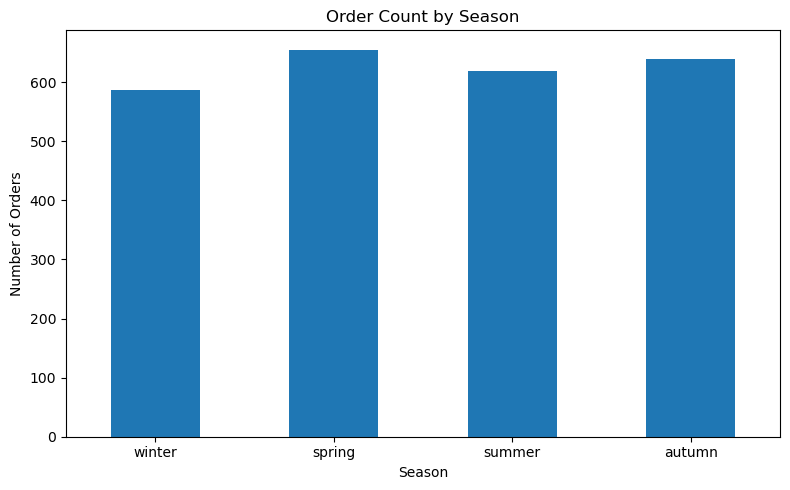

,order_count
season,
winter,586
spring,655
summer,619
autumn,640


In [6]:
season_order = ["winter", "spring", "summer", "autumn"]
season_counts = orders_df["season"].value_counts().reindex(season_order)

plt.figure(figsize=(8, 5))
season_counts.plot(kind="bar")
plt.title("Order Count by Season")
plt.xlabel("Season")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

season_counts.to_frame("order_count")

### Findings — Seasonal Distribution

- Seasonal effects are intentionally built into the generator using product-specific demand multipliers.
- Because of this, the dataset should show some variation across seasons rather than a perfectly flat distribution.
- This is useful because reorder behaviour in real supply chains is often seasonal.
- However, the seasonal behaviour here is hand-designed rather than observed from real transactions, so it may be simpler and more predictable than real-world demand patterns.

## 6. Missing Values Check

In [7]:
missing_values = orders_df.isnull().sum().sort_values(ascending=False)
missing_values.to_frame("missing_count")

,missing_count
order_id,0
customer_id,0
customer_type,0
producer_id,0
product,0
quantity,0
unit_price,0
order_date,0
month,0
season,0


### Findings — Missing Values

- The synthetic generator is expected to produce no missing values because all fields are explicitly assigned during generation.
- This is convenient for initial modelling and testing.
- However, it is also a limitation: real operational datasets often include incomplete dates, missing identifiers, inconsistent naming, null quantities, or partially recorded prices.
- As a result, this dataset is cleaner than a realistic production dataset and may underestimate the preprocessing effort required in practice.

## 7. Class Imbalance in `is_reorder`

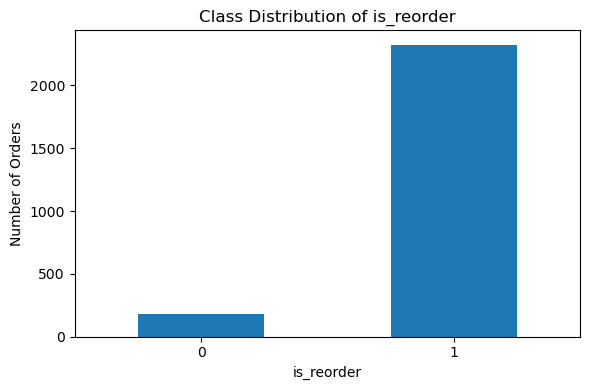

,count,percentage
is_reorder,,
0,177,7.08
1,2323,92.92


In [8]:
reorder_counts = orders_df["is_reorder"].value_counts().sort_index()
reorder_percent = (orders_df["is_reorder"].value_counts(normalize=True).sort_index() * 100).round(2)

reorder_summary = pd.DataFrame({
    "count": reorder_counts,
    "percentage": reorder_percent
})

plt.figure(figsize=(6, 4))
reorder_counts.plot(kind="bar")
plt.title("Class Distribution of is_reorder")
plt.xlabel("is_reorder")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

reorder_summary

### Findings — Target Imbalance

- The `is_reorder` target should be checked carefully because imbalance can affect model performance and interpretation.
- In a synthetic purchase history dataset, reorder cases often become frequent after enough repeated customer-product interactions are generated.
- If one class dominates, accuracy alone will become misleading.
- For this reason, evaluation should later include precision, recall, F1-score, and confusion matrix analysis rather than relying only on raw accuracy.
- If the imbalance is strong, class weighting or resampling methods may be required during modelling.

## 8. Additional Basic Checks

In [9]:
print("Duplicate order_id values:", orders_df["order_id"].duplicated().sum())
print("Unique customers in orders:", orders_df["customer_id"].nunique())
print("Unique producers in orders:", orders_df["producer_id"].nunique())
print("Unique products in orders:", orders_df["product"].nunique())

orders_df[["quantity", "unit_price", "month"]].describe().T

Duplicate order_id values: 0
Unique customers in orders: 15
Unique producers in orders: 8
Unique products in orders: 12


,count,mean,std,min,25%,50%,75%,max
quantity,2500.0,10.850800,8.896212,1.0,4.00,8.00,15.00,56.0
unit_price,2500.0,1.904172,1.132712,0.9,1.23,1.51,2.03,7.4
month,2500.0,6.573600,3.436351,1.0,4.00,7.00,10.00,12.0


### Findings — Data Quality Checks

- Order identifiers should be unique.
- Quantities and prices should remain positive and within a sensible synthetic range.
- The dataset should cover multiple customers, producers, and products rather than collapsing into a narrow subset.
- These checks confirm that the generator is behaving as intended before model training begins.


## 9. Limitations of the Dataset

The following limitations should be stated clearly in the technical report:

1. **Synthetic rather than real data**  
   The dataset is artificially generated using predefined rules, so it does not capture the full messiness or unpredictability of real customer purchasing behaviour.

2. **Rule-based bias**  
   Customer preferences, order sizes, and seasonal effects are manually designed into the generator. This means patterns in the data reflect the assumptions of the script, not observed business behaviour.

3. **Possible class imbalance**  
   The `is_reorder` target may be imbalanced, which can bias the model toward the majority class and make simple accuracy misleading.

4. **Limited feature realism**  
   The dataset does not include many real-world factors that influence purchasing decisions, such as promotions, delivery delays, stock shortages, competitor prices, weather, holidays, customer budgets, or sudden demand shocks.

5. **Clean data with little noise**  
   There are likely no missing values, no inconsistent spellings, and very few outliers. This makes the modelling process easier than it would be with a real production dataset.

6. **Small entity space**  
   The number of customers, producers, and products is limited. This makes the prediction task manageable, but it may reduce how well the model generalises to a larger and more diverse environment.

7. **Simplified reorder logic**  
   The `is_reorder` label is derived from whether a customer previously bought the same product. Real reorder behaviour can depend on timing, changing preferences, context, and substitution behaviour, which are not modelled here.

8. **Temporal realism is limited**  
   Although dates and seasons are included, the sequence of orders is still synthetic and may not fully reflect realistic weekly, monthly, or event-driven purchasing patterns.

9. **Potential distribution imbalance across groups**  
   Some products, customer types, or seasons may appear more often than others. This can introduce bias into the trained model and should be acknowledged.

## 10. Summary

This exploratory analysis shows that the generated dataset is structured and suitable for developing an initial purchase prediction pipeline. The plots help reveal how orders are distributed across products, customer types, and seasons, while the missing value and class balance checks confirm whether the dataset is ready for preprocessing and modelling. At the same time, the dataset has clear limitations because it is synthetic, rule-driven, and cleaner than a real operational dataset. These limitations should be acknowledged explicitly in the report so that the model results are interpreted honestly and within the correct context.